<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="../Images/Xlogo.png" alt="logo" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong> APM_52448_EP - Deep Learning in Finance   </strong></p>
    <p style=" text-align: center; font-size: 30px;"> 
    <strong> Tutorial 2: Brownian motion in Finance, and the Black-Scholes model </strong></p>
  <p style=" text-align: left; font-size: 20px;"> Olivier Féron </p>
</header>

# Objectives

- Implementation of the Black-Scholes (Geometric Brownian Motion) Model
- Simulation of price trajectories
- Empirical analysis of the mean and volatility
- Effect of parameters and time discretization

# Introduction
## The modeling puzzle

**Question:** What is a `model`?

A `model` is an umbrella term that refers to a simplification of a complex reality embodying different concepts such as fashion models, scale models, `scientific models`.

For scientists, a `model` is more precisely a mathematical representation of the world used to:

- Understand
- Describe
- Predict

Yet, it still has to verify certain properties to be recognized as a successful model before being adopted in practice. Two such key properties are **consistency** and **tractability**.

**Consistency:**
A model is said to be consistent if it `captures`, to some extent, the stylized facts of the observations. The more complex a model is, e.g.~with a large number of parameters, the more detailed the description of the reality, the more simplistic the more it drifts away from real life.

**Tractability:** A model is said to be `tractable` if it produces its outputs in a reasonable time.

In a utopian world, ideal models would provide a perfect balance between **consistency** and **tractability**:
- replicate the stylized facts of the empirical observations
- predict relevant outputs in a time-efficient fashion.

Finding such `models` is without any doubt a myth.

How much **consistency** is a scientist willing to sacrifice for **tractability**?

To answer this question, a picture is worth a thousand words.

<img src="../Images/fig_intro.png" alt="Transposition of a vector" title="Vector transposition" width="700">



"Everything should be made as simple as possible, but not simpler" - Albert Einstein

---


## Building a good model

Focus on one particular class: **equities**

- Flexibility: replicate stylized facts 
- Tractability: fast computations of options prices

**Understand**

**Daily evolution of S&P500**
<img src="../Images/SP.png" alt="Transposition of a vector" title="Vector transposition" width="700">

- The price is always positive,
- The price is random?



## Why Randomness?  🤔

<!-- <img src="images/rock3.png" alt="Transposition of a vector" title="Vector transposition" width="700"> -->


---



## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from scipy.stats import norm

# 1. Black–Scholes Model

We consider the continuous-time process

$$
\frac{dX_t}{X_t} = \mu\, dt + \sigma\, dW_t.
$$

For a time discretization with step $\Delta t$, the exact simulation scheme is

$$
X_{t+\Delta t} = X_t 
\exp\Bigl\{\bigl(\mu - \tfrac{1}{2}\sigma^2\bigr)\Delta t
     + \sigma \sqrt{\Delta t}\,\varepsilon \Bigr\},
$$

where $\varepsilon \sim \mathcal{N}(0,1)$.

Note: The discretized version of the Black-Scholes model is obtained with the change of variable $Y_t = \ln X_t$ and applying Itô's formula (Exercise)
<figure>
  <figcaption><strong>Table 1 — Parameter values</strong></figcaption>

| Paramter | Value |
|:------:|:------:|
|$\mu$ | $10\%$ |
|$\sigma$ | $15\%$ |
|$X_0$ | $100$ |
|$t_0$ | 2026/01/01 |
|$T$ | 2026/12/31 |
</figure>

<span style="color: red;">**1.1** Generate trajectories from the Black-Scholes model, from $t_0$ to $T$, with the parameters given in Table 1</span>

Number of dates: 365, dt = 0.002740 years


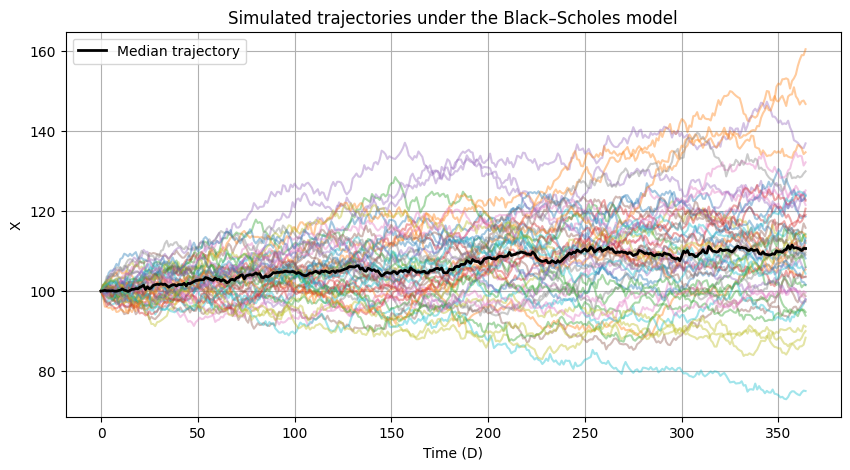

In [2]:
# --- Simulation horizon (in years) ---
# Format 'dd/mm/yyyy HH:MM:SS'
t_0 = datetime.strptime('01/01/2026 00:00:00', '%d/%m/%Y %H:%M:%S')
T   = datetime.strptime('31/12/2026 00:00:00', '%d/%m/%Y %H:%M:%S')

# 'D' for daily, 'h' for hourly simulation
Frequency = 'D'

# Build the list of simulation dates
Datelist = pd.date_range(start=t_0, end=T, freq=Frequency).tolist()

# Time step (in years)
Diff_date = Datelist[1] - Datelist[0]
dt = Diff_date.total_seconds() / (365 * 24 * 3600)
print(f"Number of dates: {len(Datelist)}, dt = {dt:.6f} years")

# --- Black–Scholes parameters ---
mu = 0.10  # drift: 10%
sigma = 0.15   # volatility: 15%
X0 = 100  # initial value

Nb_simulations = 50  # number of simulated trajectories

def Simulate_Price_Black_Scholes(initial_value, tendency, volatility, nb_simulations, Datelist):
    """
    Simulates price trajectories using the Black-Scholes model.
                dS_t = mu S_t dt + sigma S_t dW_t
                
    Inputs:
    initial_value    : initial value of the underlying price.
    tendency         : drift term (mu) in the Black-Scholes model.
    volatility       : volatility term (sigma) in the Black-Scholes model.
    nb_simulations   : number of simulations to run.
    Datelist         : list of simulation dates
    
    Output:
    trajectories : A 2D array where each row represents a simulated price trajectory.
    """
    Diff_date = Datelist[1] - Datelist[0]
    dt = Diff_date.total_seconds() / (365 * 24 * 3600)

    L = len(Datelist)
    # Initialize the array to store the simulated trajectories
    trajectories = np.zeros((nb_simulations, L))
    
    # Set the initial value for all simulations
    trajectories[:, 0] = initial_value
    
    # Simulate the trajectories
    for t in range(1, L):
        # Generate Gaussian random variables from N(0, sqrt(dt))
        dWt = np.random.normal(0, np.sqrt(dt), nb_simulations)
        
        # Calculate the price at the next time step
        trajectories[:, t] = trajectories[:, t-1] * np.exp((tendency - 0.5 * volatility**2) * dt + volatility * dWt)
    
    return trajectories


X = Simulate_Price_Black_Scholes(X0, mu, sigma, Nb_simulations, Datelist)

plt.figure(figsize=(10, 5))

for k in range(50):
    plt.plot(X[k, :], alpha=0.4)

median_trajectory = np.median(X, axis=0)
plt.plot(median_trajectory, color='black', label='Median trajectory', linewidth=2)

plt.title('Simulated trajectories under the Black–Scholes model')
plt.xlabel(f"Time ({Frequency})")
plt.ylabel('X')
plt.legend()
plt.grid(True)
plt.show()

### Basic Check

<span style="color: red;">**1.2** Compute the theoretical mean $\mathbb{E}[X_t]$, for $t \in [0~;~T]$ and compare to the empirical one</span>

<span style="color: red;">**1.3** Compute the theoretical standard deviation $\sqrt{\text{Var}\left[\ln\frac{X_t}{X_0}\right]}$, for $t \in [0~;~T]$ and compare to the empirical one</span>



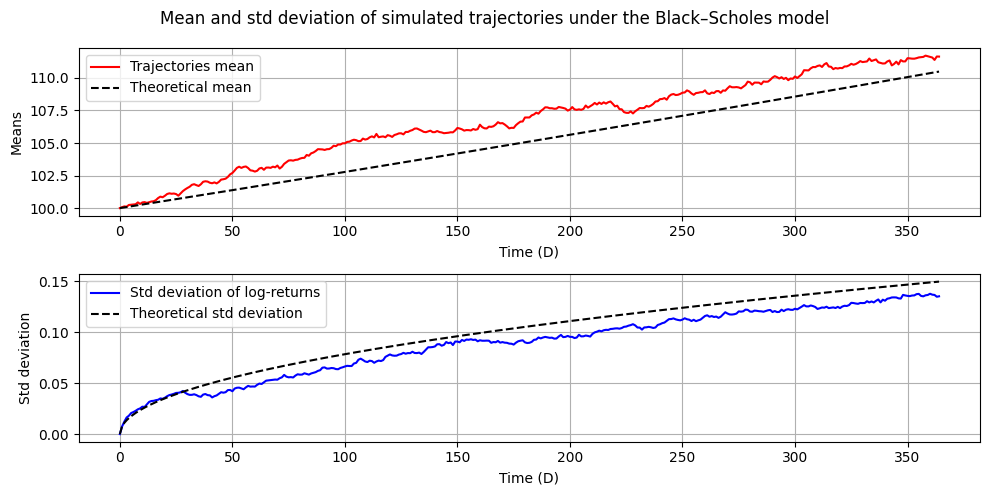

In [3]:
std = np.std(np.log(X) - np.log(X0), axis=0)
mean = np.mean(X, axis=0)

time = np.arange(0, dt * len(Datelist), dt)
mean_th = X0 * np.exp(mu * time)
std_th = sigma * np.sqrt(time)

fig = plt.figure(figsize=(10, 5))
fig.suptitle('Mean and std deviation of simulated trajectories under the Black–Scholes model')

subfig = fig.add_subplot(2, 1, 1)
subfig.plot(mean, label='Trajectories mean', color='red')
subfig.plot(mean_th, label='Theoretical mean', color='black', linestyle='--')
subfig.set_xlabel(f"Time ({Frequency})")
subfig.set_ylabel('Means')
subfig.grid(True)
subfig.legend()

subfig = fig.add_subplot(2, 1, 2)
subfig.plot(std, label='Std deviation of log-returns', color='blue')
subfig.plot(std_th, label='Theoretical std deviation', color='black', linestyle='--')
subfig.set_xlabel(f"Time ({Frequency})")
subfig.set_ylabel('Std deviation')
subfig.grid(True)
subfig.legend()

fig.tight_layout()
plt.show()

### Empirical study

**Impact of the number of simulations**

- <span style="color: red;">**1.3** Modify `Nb_simulations` (e.g. 100 / 1,000 / 100,000) and observe the stability of the empirical mean.</span>


**Effects of $\mu$ and $\sigma$**

- <span style="color: red;">**1.4** Increase or decrease `mu` (e.g. -10%, 0%, 10%) and observe the impact on the simulations.</span>  
- <span style="color: red;">**1.5** Increase or decrease `sigma` (e.g. 1%, 10%, 100%) and observe the impact on the simulations.</span>



**Impact of time discretization**

- <span style="color: red;">**1.6** Switch to hourly steps with `Frequency = 'h'` and observe the impact on the simulations.</span>

In [4]:
# No single way I am doing that.

# 2. Option valuation

We are now interested in the valuation of a Call option of strike $K$, maturity $T$ and underlying $X$. Let's first recall the payoff of such an option :
$$
CF(T) = (X_T - K)^+
$$

We consider a risk-free rate $r=1\%$ and the model parameters given in Table 1.

We know that, under AOA assumption, any option price is given by the expectation of its discounted cash-flows under the risk-neutral probability. Therefore the value $C$ of the Call option is given by:

$$
C(t_0) = \mathbb{E} \left[ e^{-r(T-t_0)} (X_T - K)^+ | \mathcal{F}_{t_0}\right]
$$

When $X$ is driven by a Black-Scholes model, this leads to the Black-Scholes formula:

$$
C(t_0) = X_0 \phi(d_1(t_0)) - K e^{-r(T-t_0)} \phi(d_2(t_0))
$$
with
$$
d_1(t_0) = \frac{1}{\sigma \sqrt{T-t_0}} \left(\ln \frac{X_0}{K} + \left(r+ \frac{\sigma^2}{2} \right)(T-t_0) \right), \qquad \qquad d_2(t_0) = d_1(t_0) - \sigma \sqrt{T-t_0}
$$
and $\phi$ the cumulative distribution function of a $\mathcal{N}(0~;~1)$


<span style="color: red;">**2.1** Compute the value of the ''in the money' Call option at time $t=0$</span>

<span style="color: red;">**2.2** From the trajectories of $X$ previously simulated, compute the expected cash-flows of the Call option and compare to the Call option value</span>

<span style="color: red;">**2.3** Plot the histogram of the Call option cash-flows</span>



<span style="color: red;"> **2.4** The Black-Scholes formula gives an explicit solution for pricing a Call option. Is there another (more general) way to access (approximate) the value of the option ?</span> 🤔 


In [5]:
def Black_Scholes_Formula(vol, risk_free_rate, current_price, strike, maturity):
    r"""
    Black_Scholes_Formula(vol, risk_free_rate, current_price, strike, maturity)
    Function computing the Black-Scholes formula to obtain the price of a Call option
    
    Inputs
    ----------
    vol            : volatility of the underlying
    risk_free_rate : value of the risk free rate
    current_price  : current value of the underlying price (X_t)
    strike         : value of the strike (K)
    maturity       : Maturity of the option (T-t)

    Output
    -------
    Value          : Call option price from BS formula : X0 \Phi(d_1) - K e^{-r(T_t)} \Phi(d_2)
    """
    # Computation of d_1 and d_2 of the Black-Scholes Formula
    d_1 = (np.log(current_price / strike) + (risk_free_rate + vol**2 / 2) * maturity) / (vol * np.sqrt(maturity))
    d_2 = d_1 - vol * np.sqrt(maturity)
    
    # Black-Scholes formula
    Value = current_price * norm.cdf(d_1) - strike * np.exp(-risk_free_rate * maturity) * norm.cdf(d_2)
    
    return Value

r = 1/100
K = X0

# Black Scholes formula
Diff_date = T - t_0
maturity = Diff_date.total_seconds() / (365 * 24 * 3600)
C = Black_Scholes_Formula(sigma, r, X0, K, maturity)
print(f"Value of the Call option at t=$t_0$: {C}")

# Monte Carlo Valuation (Risk-Neutral simulation)
X_rn = Simulate_Price_Black_Scholes(X0, r, sigma, 1000, Datelist)
C_MC = np.exp(-r * maturity) * np.mean(np.maximum(X_rn[:, -1] - K, 0))
print(f"Monte Carlo Value of the Call option at t=$t_0$: {C_MC}")

Value of the Call option at t=$t_0$: 6.4500146636040085
Monte Carlo Value of the Call option at t=$t_0$: 6.485800355392937


# 3. Computation of the replication strategy

The objective of this part is to build the replication portfolio corresponding to the Call option. 

The strategy of replication consists in starting with the initial price of the Call option: $P(t_0) = C(t_0)$ and, at each time $t \in \{t_0, t_0+dt, \dots, T-dt \}$:
- compute the Delta $$\Delta(t) = \phi(d_1(t))$$
- Split the portfolio's value $P(t)$ in two parts: $\Delta(t)P(t)$ and $P(t) - \Delta(t) P(t)$ to invest in the risky asset $X$ and the non-risky asset of return $r$, respectively, to obtain at time $t+dt$ the amount:$$ P(t+dt) = \Delta(t) X(t+dt) + (P(t) - \Delta(t)P(t))rdt $$

<span style="color: red;">**3.1** Compute the value $C(t)$ of the Call option on each time of each trajectory of $X$ </span>

<span style="color: red;">**3.2** Compute the replication portfolio's value $P(t)$ on each time of each trajectory of $X$ </span>

<span style="color: red;">**3.3** Compare the final values $C(T)$ and $P(T)$ </span>

In [6]:
Call = np.zeros_like(X)  # Table of prices C(t)
Replication_Portfolio = np.zeros_like(X)  # Array of replication portfolio values
Delta = np.zeros_like(X)  # Array of Delta

Nb_seconds_in_year = (365 * 24 * 3600)
for (i, d) in enumerate(Datelist):
    # Computation of the option price (Black-Scholes formula) and the Delta
    maturity = 

    if i == 0:
        # Initialisation 
        Call[:,i] = 
        Replication_Portfolio[:,i] = 
        
        # Computation of the first delta
        # YOUR CODE HERE 
    else: 
        Replication_Portfolio[:, i] = 
        
        if maturity > 0:# only relevant when we are not at maturity
            # YOUR CODE HERE

        else:
            # YOUR CODE HERE
        
# Plot
fig, (ax1, ax2) = plt.subplots(2,1)
index = 0
ax1.plot(Datelist, X[index,:])
ax1.axhline(y= K, linestyle = '--', color = "black")
ax1.set_title("One trajetory of underlying price")
ax2.plot(Datelist, Call[index,:], label = "Option price", color ="black", linewidth = 1)
ax2.plot(Datelist, Replication_Portfolio[index,:], label = "Replication portfolio", color ="red", linewidth = 1)
ax2.set_xlabel("Option price vs. replication portfolio value")
ax2.legend()
plt.show()

# Error between payoff and the final value of the replication portfolio
Error = Call[:,-1] - Replication_Portfolio[:,-1]
plt.figure()
plt.hist(Error/X[:,-1])
plt.title("Relative error between Replication portfolio value and the option payoff")
plt.show()

SyntaxError: invalid syntax (1663469571.py, line 8)

<h1 style="text-align: center;">Appendix</h1>


# Bachelier model


First stochastic model for the stock price has been introduced in 1903 by `Louis Bachelier` in his PhD thesis under the supervision of the celebrated  mathematician Henri Poincaré. 
	

<img src="../Images/Bachelier.jpg" alt="Transposition of a vector" title="Vector transposition" width="300" style="float: left;">
  <p style=" text-align: center; font-size: 20px;">   
    <strong> Louis Bachelier (1903) </strong></p> 
    <p style=" text-align: center; font-size: 14px;">$\bullet$ Bachelier is considered as the forefather of mathematical finance and a pioneer in the study of stochastic processes. </p>
    <p style=" text-align: center; font-size: 14px;"> $\bullet$  PhD not well received because it attempted to apply mathematics to an unfamiliar area for mathematicians
 </p>
    <p style=" text-align: center; font-size: 14px;">$\bullet$ Although Bachelier's work on random walks predated Einstein's celebrated study of Brownian motion by five years, the pioneering nature of his work was recognized only after several decades, first by Andrey Kolmogorov
 </p>  
 
 In the Bachelier model, the stock price is stochastic and follows a Brownian motion 
$$S_t = S_0  +  \sigma W_t, \quad t \leq T,  $$
where  $S_0>0$ is the initial price of the asset, $T$ is the investement horizon, and $\sigma>0$.


> What is a `Brownian motion` ?

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 1. Zooming out a random walk 🔍
 </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Given a family $\{Y_i,~i=1,\ldots,n\}$ of $n$ independent random variables with 
$$
	\mathbb P[Y_i=1]\;=\;1 - \mathbb P[Y_i=-1]
	=\frac{1}{2}
$$

we define the symmetric random walk
$$
M_0=0
	~\mbox{and}~
	M_{k} \;=\; \sum_{j=1}^k Y_j
	\quad \mbox{for}\quad 
	k=0,\ldots,n \,.
$$

By linear interpolation, define a continuous-time process:
$$
	M_t
	\;:=\; M_{\lfloor t\rfloor}
	+\left(t-\lfloor t\rfloor\right)(M_{\lfloor t\rfloor+1} - M_{\lfloor t\rfloor}) 
	\quad \mbox{for}\quad 
	t\ge 0 \,,
$$
where $\lfloor t\rfloor$ denotes the largest integer less than or equal to $t$. 



Define a stochastic process $W^n$ by speeding up time and conveniently scaling:
$$
	W^n_t
	\quad :=\quad 
	\frac{1}{\sqrt{n}} M_{nt} \,,~~t\ge 0 \,.
$$
	
  
  1. Simulate trajectory of $M$ and $W^n$ for different $n$. 



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Simulate M and interpolate

# number of jumps
n = 20

#Fix random number generator seed
np.random.seed(1)

#Simulate trajectory of m Start from M0=0 with concatenate
Mt = np.cumsum(np.concatenate(([0.],np.random.choice([-1,1],n))))

print(Mt)

plt.step(np.arange(n+1), Mt, label = 'Random walk')
plt.plot(np.arange(n+1),Mt, label ='Interpolated' )
plt.title('Random walk with interpolation')
plt.legend()
plt.show()

In [ ]:
#Simulate M and interpolate

n0, n1, n2 = 100, 1000, 1000000

Z0, Z1, Z2 = np.random.choice([-1,1], n0), np.random.choice([-1,1], n1), np.random.choice([-1,1], n2)
X0 = np.concatenate((np.zeros(1), Z0.cumsum())) / np.sqrt(n0)              #rescaled random walk with n0 steps
X1 = np.concatenate((np.zeros(1), Z1.cumsum())) / np.sqrt(n1)              #rescaled random walk with n1 steps
X2 = np.concatenate((np.zeros(1), Z2.cumsum())) / np.sqrt(n2)              #rescaled random walk with n2 steps

plt.plot(np.linspace(0, 1, n0+1), X0, label = '$n = $' + str(n0) )
plt.plot(np.linspace(0, 1, n1+1), X1, label = '$n = $' + str(n1))
plt.plot(np.linspace(0, 1, n2+1), X2, label = '$n = $' + str(n2))
plt.legend()
plt.title("Convergence of the scaled random walk?")
plt.show()


We next set
$$
    t_{k} := \frac{k}{n} \ \mbox{ for } \ k \in \mathbb{N}.
$$
 

2. Prove the following properties of the process $W^n$:

* **Independence of increments** for $0 \leq i \leq j \leq k \leq \ell \leq n$, the increments $W_{t_{\ell}}^{n} - W_{t_{k}}^{n}$ and $W_{t_{j}}^{n} - W_{t_{i}}^{n}$ are independent,
* **First two moments** for $0 \leq i \leq k$, the two first moments of increment $W_{t_{k}}^{n} - W_{t_{i}}^{n}$ are given by 
$$
\mathbb{E}\left[W_{t_{k}}^{n} - W_{t_{i}}^{n}\right] = 0 ~~~\mbox{ and }~~~ \mathbb{V}{\rm ar}\left[W_{t_{k}}^{n} - W_{t_{i}}^{n}\right] = t_{k} - t_{i}.
$$
which shows in particular that the normalization by $n^{-1/2}$ in the definition of $W^n$ prevents the variance from blowing up,
* **Martingality** with $\mathcal{F}_{t}^{n} := \sigma(Y_{p}, p \leq \lfloor nt\rfloor)$ for $t \geq 0$, the sequence $\left\{W_{t_{k}}^{n}, k \in \mathbb{N}\right\}$ is a discrete $\left\{\mathcal{F}_{t_{k}}^{n}, k \in \mathbb{N}\right\}-$martingale:
$$
\mathbb{E}\left(W_{t_{k}}^{n} \mid \mathcal{F}_{t_{i}}^{n}\right) = W_{t_{i}}^{n} \ \ \mbox{ for } 0 \leq i \leq k \leq n.
$$
* **Quadratic variation**$$
\langle W^n, W^n\rangle_{t_{k}} := \sum_{j=1}^k \left(W_{t_{j}}^{n} - W_{t_{j-1}}^{n}\right)^2 = t_k.
$$

3. Explain why at the limit $n\to \infty$ Gaussian distribution of the increments is expected to hold?



> <p><strong><span style="color:rgb(0, 0, 255);">  The normalisation by $\sqrt{n}$ is suggested by Central Limit Theorem. 
By the so-called Donsker invariance principle, $(W^n_t)$ converges to
the standard Brownian motion as $n\to \infty$.  
</span><strong></p>  
   
    
> <p><strong><span style="color:rgb(0, 0, 255);">         Another interesting property of the rescaled random walk, which will be inherited by the Brownian motion, is the following quadratic variation result:
$$
\langle W^n, W^n\rangle_{t_{k}} = \sum_{j=1}^k \left(W_{t_{j}}^{n} - W_{t_{j-1}}^{n}\right)^2 = t_k.
$$
since $W_{t_{j}}^{n} - W_{t_{j-1}}^{n} \in \{-1, 1\}$. 
</span><strong></p>  


<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 2. Brownian motion  🎲 </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

# Definition 

<div style="border:solid 1px; border-radius:8px; padding: 6px 8px 6px 8px; margin-top: 12px; border-color:rgb(0, 62, 92, 0.5); background-color:rgb(251, 251, 251);">
    <strong>Definition</strong>. (Brownian motion) 	Let $W=\{W_t,~t\in\mathbb R_+\}$ be a stochastic process on the probability space $(\Omega,\mathcal F,\mathbb P)$. $W$ is a standard Brownian motion if
    
- $W_0=0$ and the sample paths $W_.(\omega)$ are continuous for a.e. $\omega\in\Omega$,
- $W$ has independent increments: for all $0\leq t_1<t_2\leq t_3<t_4$, $W_{t_4}-W_{t_3}$ and $W_{t_2}-W_{t_1}$ are independent.
- For all $0\leq s<t$, the distribution of $W_t-W_s$ is  $N(0,t-s)$.
</div>



# Some properties 
The Brownian motion is the simplest example of a **Gaussian process**:
- A random variable $X\in \mathbb R$ is said to follow the **Gaussian distribution** $N(\mu,\sigma^2)$ if the law of $X$ has a density given by
$$
	p(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$
- A random vector $(X_1,\dots,X_n)$ is a **Gaussian vector**
if for all $(a_1,\dots,a_n)\in \mathbb R^n$, $\sum_{i=1}^n a_i X_i$ follows the Gaussian distribution.
        
- A stochastic process $(X_t)_{t\geq 0}$ is a **Gaussian process** if for all $n\geq 1$ and $0\leq t_1<t_2 <\dots <t_n$, the random vector $(X_{t_1},\dots,X_{t_n})$ is a Gaussian vector.      
- The law of a Gaussian process is completely characterized by its mean $m(t) = \mathbb E[X_t]$ and covariance $c(s,t) = \text{Cov}[X_s,X_t]$. 


<div style="border:solid 1px; border-radius:8px; padding: 6px 8px 6px 8px; margin-top: 12px; border-color:rgb(0, 62, 92, 0.5); background-color:rgb(251, 251, 251);">
    <strong>Proposition</strong>. (Brownian motion is a Gaussian process) 
The Brownian motion is a centered Gaussian process with covariance function
$$
	c(s,t) = \mathbb E[W_s W_t]  = t\wedge s.
$$
</div>
	
<div style="border:solid 1px; border-radius:8px; padding: 6px 8px 6px 8px; margin-top: 12px; border-color:rgb(0, 62, 92, 0.5); background-color:rgb(251, 251, 251);">
    <strong>Proposition</strong>. (Brownian motion is a Martingale) 
The Brownian motion is a Martingale with respect to its own filtration, i.e. 
$$
	E[W_s | \mathcal F_t]  = W_t, \quad s\geq t.
$$
</div>


# Exercise 
Let $B$ be a Brownian motion. 
1. Prove that for all $t,s\geq 0$, $B_t \sim \mathcal N(0,t)$ and that $\mathbb E[B_s B_t] = \text{min}(s,t)$
2. Let $\lambda \in \mathbb R$, prove that $(B_t)_{t\geq 0}$, $(B_t^2-t)_{t\geq 0}$ and $(e^{\lambda B_t - \frac{\lambda^2}{2}t})_{t\geq 0}$ are martingales with respect to $\mathcal F_t:=\sigma(B_t):=\sigma\{B_s:s\leq t\}$. 
3. Let $t_0=0<t_1<\ldots<t_n=T$ be a subdivision of $[0,T]$ and $\delta = \max_{k\leq n-1} |t_{k+1}-t_k|$ (subdivision step). 
     
     a. Let $X_k=(B_{k+1}-B_k)^2 - (t_{k+1}-t_k)$ for $k=0,1,\ldots,n-1$. Prove that 
     $$ \frac{\mathbb E[X_k^2]}{(t_{k+1}-t_k)^2}  $$ is independent of $k$. 
     
     b. Deduce that $\sum_{k=0}^{n-1}(B_{t_{k+1}}-B_{t_k})^2 \to T$ in $L^2$ when $\delta \to 0$. 



<!-- <div style="float: left;">
  <img src="images/corrTD1(9).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
</div>
<div style="float: left;">
  <img src="images/corrTD1(8).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(7).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1.jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(6).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(5).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(4).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(2).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
 <div style="float: left;">
  <img src="images/corrTD1(1).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div> -->


<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 3. Simulation 📈  </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

1. Simulate a Brownian motion trajectory $(W_{t_0}, W_{t_1}, \dots, W_{t_{N}})$ over the time gride $0 = t_0 < t_1 <...  t_{N-1} < t_N = T$, where  

$$
t_i = i \frac T N, \qquad i = 0, \dots, N.
$$



> <p><strong><span style="color:rgb(0, 0, 255);">  Of course, in the simulation algorithm we can exploit the propery of independence of the Brownian increments $W_{t_{i+1}} - W_{t_i}$ over the disjoint intervals $(t_{i+1} - t_i]$.
**Recursive simulation scheme**   object $W$ defined recusrively by $W_0 = 0$ and
	$$ W_{t_{i+1}}  = W_{t_i} + \sqrt{t_{i+1} -t_i} Z^i.$$ 
with $(Z^i)_i$ independent sequence of standard gaussian. 
</span><strong></p> 





In [ ]:
np.random.seed(2)
T = 1. 
N = 1000

time_grid = np.linspace(0, T, N+1)
# N gaussienne N(0,1)
Z = np.random.randn(N)
Y = np.sqrt(T/N)*Z
Y = np.concatenate(([0.], Y))
#genere (W_0, W_t_1, ... W_{t_N})
W = np.cumsum(Y)

plt.plot(time_grid, W, label="")
plt.title("Brownian motion trajectory over N = %1.0f time steps" %N)
plt.show()

In [ ]:
np.random.seed(2)
T = 1. 
N = 10

time_grid = np.linspace(0, T, N+1)
print('time_grid:', time_grid)

# N gaussienne N(0,1)
Z = np.random.randn(N)
print('Z:', Z)

#(Y_1,...,Y_N)
Y = np.sqrt(T/N)*Z
print('Y:',Y)

Y = np.concatenate(([0.], Y))
print('Y:',Y)

#genere (W_0, W_t_1, ... W_{t_N})
W = np.cumsum(Y)


2. Let  $t_0 > 0$, and $c > 0$.
Plot the following processes
    <ul>
    <li>$X^1= \left(-W_t\right)_{t \geq 0}$ </li>
    <li>$X^2 = \left(c^{-1/2}W_{ct}\right)_{t \geq 0}$</li>
    <li>$X^3= \left(W_{t + t_0} - W_{t_0}\right)_{t \geq 0}$ </li>
    <li>$X^4 =\left(W_{T - t} - W_T\right)_{t \geq 0}$ </li>
    <li>$X^5_0 := 0$ and $X^5_t := tW_{1/t}, t > 0$</li>
    </ul>


In [ ]:
import numpy as np
import matplotlib.pyplot as plot
plot.rcParams['figure.figsize'] = [16, 9]
 
m = 10000
c = 4

dW = np.random.normal(0, 2/np.sqrt(m), m)
W0 = np.concatenate([np.zeros(1), dW.cumsum()])                          #discritized Brownian Motion
W = W0[0:(m//4+1)]
W_sym = -W          
W_scale = 0.5*W0
W_trans = W0[(m//8):(m//8 + m//4+1)] - W0[m//8]
W_rev = np.flip(W) - W[m//4]

plot.plot(np.linspace(0, 1, m//4+1), W)
plot.plot(np.linspace(0, 1, m//4+1), W_sym)
plot.plot(np.linspace(0, 1, m+1), W_scale)
plot.plot(np.linspace(0, 1, m//4+1), W_trans)
plot.plot(np.linspace(0, 1, m//4+1), W_rev)
plot.title("Scaling, symmetry, and time translation / reversal")
plot.xlabel("$t$")
plot.legend(["$W_t$", "$-W_t$", "$W_{4t}/2$", "$W_{t + 1/2} - W_{1/2}$", "$W_{1-t} - W_{1}$"])
plot.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plot
plot.rcParams['figure.figsize'] = [16, 9]

T = 10.
m = 5000
tp = np.linspace(1, T, m)               #size m
tm = np.flip(1/tp)
t = np.concatenate([tm, tp[1:m]])       #size 2*m - 1
dt = t[1:(2*m-1)] - t[0:(2*m-2)]          #size 2*m - 2

dW = np.random.normal(0, np.sqrt(dt), 2*m-2)

W = np.concatenate([np.zeros(1), dW.cumsum()])
B = t*np.flip(W)

plot.plot(t, W)
plot.plot(t, B)
plot.xlabel("$t$")
plot.legend(["$W_t$", "$tW_{1/t}$"])
plot.title("A Brownian motion path and its time inversion version")
plot.show()


3. Based on the plots, what can you conjecture on these processes? Prove it.

> <p><strong><span style="color:rgb(0, 0, 255);">      All of these processes are again Brownian motion, they can be obtained by verifying that these processes are centered Gaussian processes with the appropriate covariance function.  
</span><strong></p> 


    
<div style="float: left;">
  <img src="images/corrTD3(1).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
</div>
<div style="float: left;">
  <img src="images/corrTD3(2).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD3(3).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>


<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 4. Stochastic integral  $∫_📐 dW$  </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

1. Show that  the total (one) variation of the Brownian motion is infinite:
 $$
\lim_{n\to\infty} \sum_{i\ge 1} \left| W_{t^n_i\wedge t}-W_{t_{i-1}^n\wedge t} \right| = \infty \quad \text{in } L^2.
 $$


> <p><strong><span style="color:rgb(0, 0, 255);"> First, observe the inequality
 $$
\sum_{i\ge 1} \left( W_{t^n_i\wedge t}-W_{t_{i-1}^n\wedge t}\right)^2 \le \max_{i\ge 1}\left|W_{t^n_i\wedge t}-W_{t_{i-1}^n\wedge t}\right|\; \sum_{i\ge 1} \left| W_{t^n_i\wedge t}-W_{t_{i-1}^n\wedge t} \right|\,,
 $$
    The result follows from the fact that that $\max_{i\ge 1}\left|W_{t^n_i\wedge t}-W_{t_{i-1}^n\wedge t}\right|\longrightarrow 0$, due to the continuity of the Brownian motion. For this reason, the Stieltjes theory of integration does not apply to the Brownian motion.

</span><strong></p> 


<div style="float: left;">
  <img src="images/corrTD3(4).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD3(5).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>


2. Let $(\theta)_{t\geq 0}$ be an elementary process.
   
   (i) Prove that $(\int_0^t \theta_s dW_s)_{t\geq 0}$ and $((\int_0^t \theta_s dW_s)^2 - \int_0^t \theta_s^2 ds)$ are  martingales with respect to the Brownian filtration. 
    
   
   (ii) Compute $\mathbb E [(\int_0^T \theta_s dW_s)^2]$
   
   (iii)  Assume that $\theta$ is determinstic. Provide the law of $\int_0^T \theta_s dW_s$.  
   
3. Let $f,g$ be a measurable function such that $\int_0^T f^2(s) ds <\infty$ and $\int_0^T g^2(s) ds<\infty$. What can you say about the distribution of $\int_0^T f(s)dW_s$? What about $\mbox{Cov}(\int_0^T g(s)dW_s, \int_0^T f(s)dW_s)$?
   
    
       
       
<div style="float: left;">
  <img src="images/corrTD3(6).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD3(7).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
 <div style="float: left;">
  <img src="images/corrTD3(8).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
 
 <div style="float: left;">
  <img src="images/corr_nov2 (6).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corr_nov2 (5).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
 <div style="float: left;">
  <img src="images/corr_nov2 (4).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
  <div style="float: left;">
  <img src="images/corr_nov2 (3).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corr_nov2 (2).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
 <div style="float: left;">
  <img src="images/corr_nov2 (1).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 5. First look at Black-Scholes</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

No interest in the community in the work of Bachelier, although the Russian mathematician  Kolmogorov has cited Bachelier... Growing interest starting 1960s, Robert Merton,  Fisher Black and Myron Scholes model

<img src="images/BS.jpg" alt="Transposition of a vector" title="Vector transposition" width="500">


Scholes received the 1997 Nobel Memorial Prize in Economic Sciences, Black  wasn't awarded because he died in 1995.





Let $W$ be a scalar Brownian motion and $S_t=S_0e^{\int_0^t(r-\frac{\sigma^2}{2})(s)ds+\int_0^t\sigma(s)dW_s}$, for some constant $S_0>0$, and some deterministic functions $r$ and $\sigma$. 
  
  <ol>
<li>Provide an explicit expression of $\mathbb{P}[S_T\ge K]$ for some $K>0$ in terms of the cdf $\mathbf{N}$ of the standard $\mathcal{N}(0,1)$ distribution.</li>
<li> Provide an explicit expression of $\mathbb{E}[e^{-\int_0^T r(s)ds}(S_T-K)^+]$.
<li> Prove that $S$ solves a stochastic differential equation. 

 </div>
 <div style="float: left;">
  <img src="images/CorrTD5 (11).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
 </div>
 <div style="float: left;">
  <img src="images/CorrTD5 (12).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
 <div style="float: left;">
  <img src="images/CorrTD5 (1).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
  <div style="float: left;">
  <img src="images/CorTD5 (2).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (3).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (4).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (5).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (6).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (7).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (8).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (9).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (10).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (2).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (11).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (12).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (13).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (14).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 6. Itô's formula and heat equation 🔥 </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Use the Ito formula to write each of the following stochastic processes $(X_t)_{t\geq 0}$ as Itô
processes:

1. $X_t = e^{t/2}\cos(W_t)$
    
2. $X_t = e^{t/2} sin(W_t)$
    
3. $X_t = (W_t + t)e^{-W_t -  t/2}$



   <div style="float: left;">
  <img src="images/CorTD5 (15).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (16).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (17).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
 
   <div style="float: left;">
  <img src="images/CorTD5 (18).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
   <div style="float: left;">
  <img src="images/CorTD5 (1).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> References 📖  </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;">

</div>

$\bullet$ Shreeve, S. E. (2004). Stochastic Calculus for Finance II: Continuous Time Models.